# 🧬 A Gentle Introduction to Analysing Your Data with Python
**Workshop — Konstantinos Kalaitzidis**

---

We will walk through an example of a data analysis pipeline for inspecting biological data. 
By the end of the session you will have loaded, cleaned, explored, and visualised a real biological dataset in Python.

**What we'll cover:**
1. Loading & Inspecting Data
2. Data Cleaning
3. Exploratory Statistics
4. Visualisation

## How to use this notebook

Each section has:
- A **narrative cell** (like this one) explaining the concept
- A **code cell** below that you run with `Shift + Enter`

You have your own copy — feel free to edit, break things, and experiment.
That is the best way to learn.

>If something breaks: `Runtime → Restart and run all` to start fresh.


## The Data Analysis Pipeline

Every project follows roughly the same steps:

```
Raw Data → Load → Inspect → Clean → Explore → Visualise → Model
```

Today's dataset: **clinical measurements from breast tumor biopsies**
(Breast Cancer Wisconsin Dataset).

- **569 patient samples**, 30 numerical features per sample
- Features: cell radius, texture, perimeter, area, smoothness, concavity…
- Target: `diagnosis` — Malignant or Benign

📄 **Dataset resources:**
- [UCI ML Repository](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic)
- [scikit-learn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html)

---
## 1. 💻 Getting Started with Google Colab

Google Colab is a free, cloud-based environment for running Python notebooks
directly in your browser — no installation needed.

**The golden rule: run cells in order, from top to bottom.**
Each cell may depend on the ones above it. Skipping a cell or running
things out of order is the most common cause of errors.

---

### Running cells

| Action | How |
|---|---|
| Run a cell and move to the next | `Shift + Enter` |
| Run a cell and stay | `Ctrl + Enter` |
| Run all cells from top to bottom | `Runtime → Run all` |
| Restart and run all (fix most problems) | `Runtime → Restart and run all` |

> 💡 If something breaks or behaves unexpectedly, `Runtime → Restart and run all`
> fixes 90% of problems. It clears all variables and re-runs the notebook fresh.

---

### Your copy is yours

Because you clicked **"Copy to Drive"**, this is your personal copy.
Whatever you run, edit, or break only affects your notebook —
not anyone else's, and not the original.

---

In [1]:
# Use ? to pull up documentation for any function
# Run this cell and a help panel will appear at the bottom
import pandas as pd
pd.read_csv?


Signature:
pd.read_csv(
    filepath_or_buffer: 'FilePath | ReadCsvBuffer[bytes] | ReadCsvBuffer[str]',
    *,
    sep: 'str | None | lib.NoDefault' = <no_default>,
    delimiter: 'str | None | lib.NoDefault' = None,
    header: "int | Sequence[int] | None | Literal['infer']" = 'infer',
    names: 'Sequence[Hashable] | None | lib.NoDefault' = <no_default>,
    index_col: 'IndexLabel | Literal[False] | None' = None,
    usecols: 'UsecolsArgType' = None,
    dtype: 'DtypeArg | None' = None,
    engine: 'CSVEngine | None' = None,
    converters: 'Mapping[Hashable, Callable] | None' = None,
    true_values: 'list | None' = None,
    false_values: 'list | None' = None,
    skipinitialspace: 'bool' = False,
    skiprows: 'list[int] | int | Callable[[Hashable], bool] | None' = None,
    skipfooter: 'int' = 0,
    nrows: 'int | None' = None,
    na_values: 'Hashable | Iterable[Hashable] | Mapping[Hashable, Iterable[Hashable]] | None' = None,
    keep_default_na: 'bool' = True,
    na_filter: '

In [2]:
!python --version

Python 3.10.20


---
## 2. Loading & Inspecting Data

The first step in any analysis: load your data and understand its structure.

**pandas** 🐼 is the go-to Python library for tabular data.
Think of it as a supercharged spreadsheet you control with code.

A pandas **DataFrame** is just a table — rows are samples, columns are features.


In [3]:
# ── Imports ──────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set up plotting style
%matplotlib inline
# Set the theme for seaborn
sns.set_theme(style="whitegrid")

print("✅ All libraries loaded!")


✅ All libraries loaded!


In [ ]:
# ── Load the dataset ─────────────────────────────────────────────────────
# We load from a CSV file stored in the repository.
# This works both locally and in Colab via the raw GitHub URL.

# Local path to the dataset
import os

# Define both local path and GitHub URL
LOCAL_PATH = "data/breast_cancer.csv"
# GITHUB_URL = "https://raw.githubusercontent.com/konkalaitzidis/2026-05-07-python-workshop/main/data/breast_cancer.csv"

if os.path.exists(LOCAL_PATH):
    df = pd.read_csv(LOCAL_PATH)
    print("Loaded from local file.")
else:
    df = pd.read_csv(GITHUB_URL)
    print("Loaded from GitHub.")

# Display the shape of the dataset
print(f"Dataset loaded: {df.shape[0]} samples, {df.shape[1]} columns")


Loaded from local file.
Dataset loaded: 569 samples, 32 columns


In [ ]:
# Quick peek
df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis,diagnosis_label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


In [ ]:
# How big is the dataset?
print("Shape (rows, columns):", df.shape)
print()

# What are the columns and their data types?
print("Column types:")
print(df.dtypes)


Shape (rows, columns): (569, 32)


Column types:
mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst 

In [ ]:
# How balanced is our target?
print("Diagnosis distribution:")
print(df['diagnosis_label'].value_counts())
print()

# Let's also look at the proportions
print(df['diagnosis_label'].value_counts(normalize=True).round(2))


Diagnosis distribution:
diagnosis_label
benign       357
malignant    212
Name: count, dtype: int64

diagnosis_label
benign       0.63
malignant    0.37
Name: proportion, dtype: float64


---
## 3. Data Cleaning

Real-world data is messy. You will almost always encounter:
- **Missing values** (NaN)
- **Wrong data types**
- **Inconsistent labels or column names**

Let's simulate a realistic scenario by introducing missing values,
then handle them properly.

**Key functions:**

| Function | What it does |
|---|---|
| `df.isnull().sum()` | Count missing values per column |
| `df.fillna(value)` | Fill missing values |
| `df.dropna()` | Drop rows with missing values |
| `df.rename(columns={...})` | Rename columns |
| `df.loc[rows, cols]` | Select by label |
| `df.iloc[rows, cols]` | Select by position |


In [24]:
# Simulate missing data — as you'd find in a real clinical dataset
np.random.seed(42) # For reproducibility
df_messy = df.copy() 

# Randomly set 20 values in 'mean radius' to NaN
idx1 = np.random.choice(df_messy.index, size=20, replace=False) # Randomly select 20 indices
df_messy.loc[idx1, 'mean radius'] = np.nan # Set those indices in 'mean radius' to NaN

# And 10 values in 'mean texture'
idx2 = np.random.choice(df_messy.index, size=10, replace=False) # Randomly select 10 indices
df_messy.loc[idx2, 'mean texture'] = np.nan # Set those indices in 'mean texture' to NaN

print("Missing values introduced. Let's find them...")


Missing values introduced. Let's find them...


In [27]:
# Check for missing values across all columns
missing = df_messy.isnull().sum()
missing.head()

mean radius        20
mean texture       10
mean perimeter      0
mean area           0
mean smoothness     0
dtype: int64

In [28]:
# Only show columns that actually have missing values
print("Columns with missing values:")
print(missing[missing > 0])

Columns with missing values:
mean radius     20
mean texture    10
dtype: int64


In [29]:
# How would you fill the missing values in 'mean radius'?
# A common approach: fill with the column mean.

# Solution
df_messy['mean radius']  = df_messy['mean radius'].fillna(df_messy['mean radius'].mean()) # Fill NaNs with the mean of 'mean radius'
df_messy['mean texture'] = df_messy['mean texture'].fillna(df_messy['mean texture'].mean()) # Fill NaNs with the mean of 'mean texture'

# Verify
remaining = df_messy.isnull().sum().sum() # Total remaining missing values across the dataset
print(f"Missing values remaining: {remaining}")
print("✅ Dataset is clean!")


Missing values remaining: 0
✅ Dataset is clean!


In [30]:
# Renaming columns for readability
df_clean = df_messy.rename(columns={
    'mean radius':   'radius',
    'mean texture':  'texture',
    'mean area':     'area',
    'mean smoothness': 'smoothness'
})

# Selecting a subset of columns with loc
subset_cols = ['radius', 'texture', 'area', 'smoothness', 'diagnosis_label']
df_subset = df_clean.loc[:, subset_cols]
df_subset.head()

,radius,texture,area,smoothness,diagnosis_label
0,17.99,10.38,1001.0,0.11840,malignant
1,20.57,17.77,1326.0,0.08474,malignant
2,19.69,21.25,1203.0,0.10960,malignant
3,11.42,20.38,386.1,0.14250,malignant
4,20.29,14.34,1297.0,0.10030,malignant


In [31]:
# Filtering rows — e.g. only malignant samples
malignant = df[df['diagnosis_label'] == 'malignant']
benign = df[df['diagnosis_label'] == 'benign']

print(f"Malignant samples : {len(malignant)}")
print(f"Benign samples    : {len(benign)}")

Malignant samples : 212
Benign samples    : 357


---
## 4. Exploratory Statistics

Before building any model, we explore the data to develop intuition:

- What is the range of values?
- Are there differences between groups?
- Which features are correlated with each other?

**Key functions:**

| Function | What it does |
|---|---|
| `df.describe()` | Summary statistics (min, max, mean, etc) |
| `df.groupby(col).mean()` | Compare group averages |
| `df.corr()` | Pairwise correlations between all features |


In [ ]:
# Summary statistics for all numeric columns
df.describe().round(2) # Round to 2 decimal places for better readability

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
count,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,...,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10,0.10,0.09,0.05,0.18,0.06,...,25.68,107.26,880.58,0.13,0.25,0.27,0.11,0.29,0.08,0.63
std,3.52,4.30,24.30,351.91,0.01,0.05,0.08,0.04,0.03,0.01,...,6.15,33.60,569.36,0.02,0.16,0.21,0.07,0.06,0.02,0.48
min,6.98,9.71,43.79,143.50,0.05,0.02,0.00,0.00,0.11,0.05,...,12.02,50.41,185.20,0.07,0.03,0.00,0.00,0.16,0.06,0.00
25%,11.70,16.17,75.17,420.30,0.09,0.06,0.03,0.02,0.16,0.06,...,21.08,84.11,515.30,0.12,0.15,0.11,0.06,0.25,0.07,0.00
50%,13.37,18.84,86.24,551.10,0.10,0.09,0.06,0.03,0.18,0.06,...,25.41,97.66,686.50,0.13,0.21,0.23,0.10,0.28,0.08,1.00
75%,15.78,21.80,104.10,782.70,0.11,0.13,0.13,0.07,0.20,0.07,...,29.72,125.40,1084.00,0.15,0.34,0.38,0.16,0.32,0.09,1.00
max,28.11,39.28,188.50,2501.00,0.16,0.35,0.43,0.20,0.30,0.10,...,49.54,251.20,4254.00,0.22,1.06,1.25,0.29,0.66,0.21,1.00


In [14]:
# Compare feature means between malignant and benign tumors
features_to_compare = ['mean radius', 'mean texture', 'mean area',
                       'mean smoothness', 'mean concavity']

group_means = df.groupby('diagnosis_label')[features_to_compare].mean()
print("Mean feature values by diagnosis:")
group_means.round(3)

Mean feature values by diagnosis:


,mean radius,mean texture,mean area,mean smoothness,mean concavity
diagnosis_label,,,,,
benign,12.147,17.915,462.790,0.092,0.046
malignant,17.463,21.605,978.376,0.103,0.161


In [32]:
# Correlation matrix — which features move together?
selected = ['mean radius', 'mean texture', 'mean area',
            'mean smoothness', 'mean concavity', 'mean symmetry']

corr_matrix = df[selected].corr().round(2)
corr_matrix

,mean radius,mean texture,mean area,mean smoothness,mean concavity,mean symmetry
mean radius,1.00,0.32,0.99,0.17,0.68,0.15
mean texture,0.32,1.00,0.32,-0.02,0.30,0.07
mean area,0.99,0.32,1.00,0.18,0.69,0.15
mean smoothness,0.17,-0.02,0.18,1.00,0.52,0.56
mean concavity,0.68,0.30,0.69,0.52,1.00,0.50
mean symmetry,0.15,0.07,0.15,0.56,0.50,1.00


---
## 5. Visualisation

We'll use two libraries:
- **matplotlib** — the foundational Python plotting library 
- **seaborn** — a higher-level library built on top of matplotlib 

**Plots we'll make:**
1. **Histogram** — distribution of a single feature across all samples. Useful for spotting skew, outliers, or whether two groups overlap.
2. **Boxplot** — great for comparing groups side by side. Summarises a distribution across groups using five numbers: minimum, lower quartile, median, upper quartile, maximum. 
3. **Scatterplot** — plots the relationship between two features. Reveals clusters and whether groups are separable in two dimensions.
4. **Heatmap** — visualises the full correlation matrix at a glance such as which features move together, and which are independent.



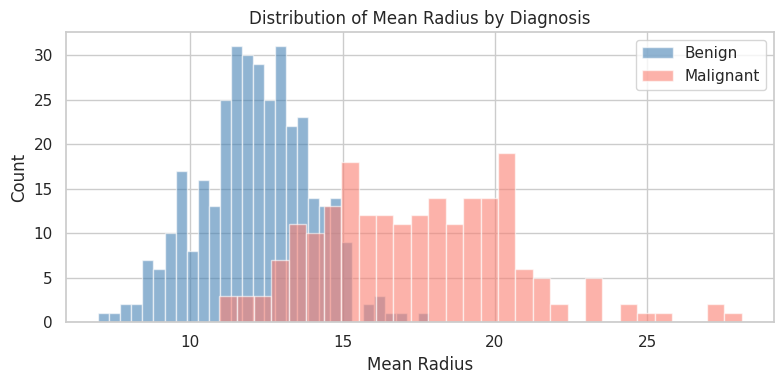

In [ ]:
# ── 1. Histogram ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4)) # Create a figure and axis for plotting

ax.hist(benign['mean radius'],    bins=30, alpha=0.6, label='Benign',    color='steelblue') 
ax.hist(malignant['mean radius'], bins=30, alpha=0.6, label='Malignant', color='salmon')

ax.set_xlabel('Mean Radius') 
ax.set_ylabel('Count')
ax.set_title('Distribution of Mean Radius by Diagnosis')
ax.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_1786084/321851743.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


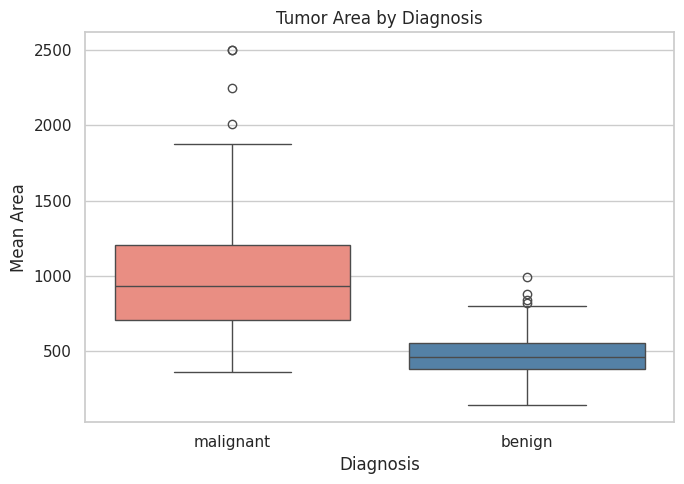

In [ ]:
# ── 2. Boxplot ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(
    data=df, x='diagnosis_label', y='mean area',
    palette={'benign': 'steelblue', 'malignant': 'salmon'},
    ax=ax
)

ax.set_title('Tumor Area by Diagnosis')
ax.set_xlabel('Diagnosis')
ax.set_ylabel('Mean Area')
plt.tight_layout()
plt.show()

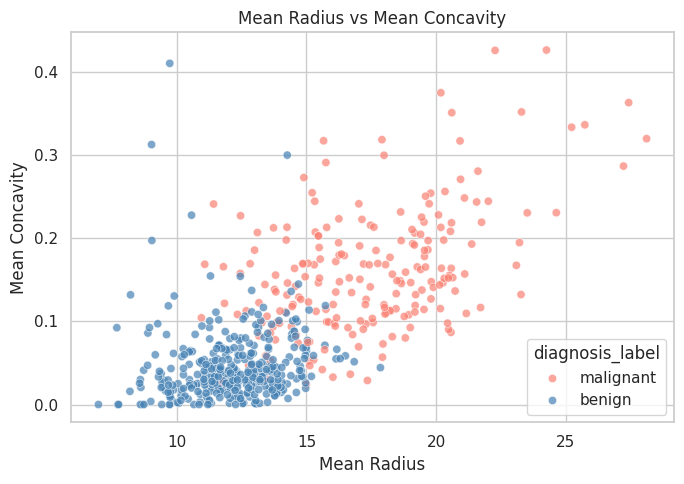

In [34]:
# ── 3. Scatterplot ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

sns.scatterplot(
    data=df, x='mean radius', y='mean concavity',
    hue='diagnosis_label',
    palette={'benign': 'steelblue', 'malignant': 'salmon'},
    alpha=0.7, ax=ax
)

ax.set_title('Mean Radius vs Mean Concavity')
ax.set_xlabel('Mean Radius')
ax.set_ylabel('Mean Concavity')
plt.tight_layout()
plt.show()

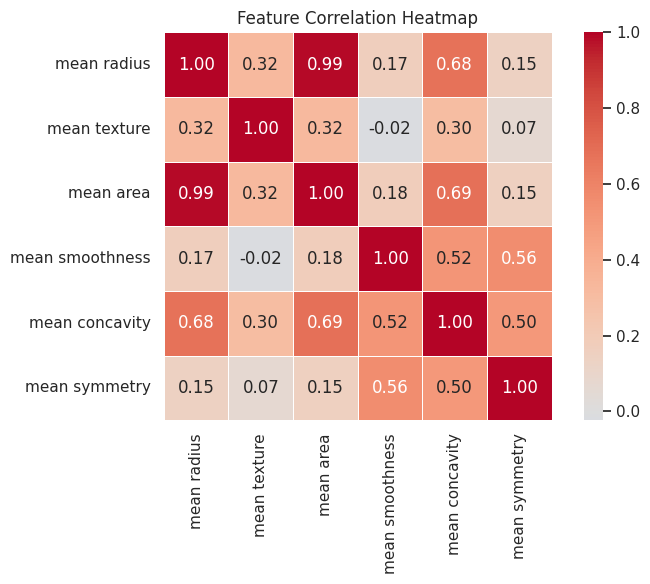

In [38]:
# ── 4. Correlation Heatmap ───────────────────────────────────────────────
selected = ['mean radius', 'mean texture', 'mean area',
            'mean smoothness', 'mean concavity', 'mean symmetry']

corr = df[selected].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax)

ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## 🔍 So what have we learned?

**1. Malignant tumors are physically larger.**
Every size-related feature such as radius, perimeter, area, is consistently higher in malignant samples. The histogram and boxplot both showed this clearly.

**2. No single feature is enough.**
The histogram showed overlap between the two groups even for the most informative features. You cannot reliably classify a tumor from one measurement alone. This is precisely why we have 30 features and why machine learning is useful here.

**3. Many features are highly correlated with each other.**
The heatmap revealed that radius, perimeter, and area are almost perfectly correlated. They all measure size in slightly different ways. In a production model, keeping all three adds noise without adding information. This is called multicollinearity. For today this is fine, but it is something to be aware of.

**4. The two classes are partially separable in 2D.**
The scatterplot of radius vs concavity showed two distinct, if overlapping, clouds. This is good. If groups are visually separable in just two dimensions, a model using all 30 features should do considerably better.

## 6. Self-Work Exercises

These exercises are for you to work through at your own pace.
Each one is a small extension of something we already did together
so you have all the tools you need. A solution is hidden beneath each exercise.
Try to solve it yourself first before revealing it.

---

### Exercise 1 — A New Histogram

We plotted the distribution of `mean radius` split by diagnosis.
Now do the same for **`mean concavity`**.

- Does the separation between malignant and benign look stronger or weaker than for radius?
- What does this tell you about how useful concavity might be as a feature?

<details>
<summary>💡 Click to reveal solution</summary>

```python
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(benign['mean concavity'],    bins=30, alpha=0.6, label='Benign',    color='steelblue')
ax.hist(malignant['mean concavity'], bins=30, alpha=0.6, label='Malignant', color='salmon')

ax.set_xlabel('Mean Concavity')
ax.set_ylabel('Count')
ax.set_title('Distribution of Mean Concavity by Diagnosis')
ax.legend()
plt.tight_layout()
plt.show()

```

You should see that the separation between groups is actually stronger for concavity than for radius —
malignant tumors have markedly higher concavity values with less overlap.
This is consistent with what the correlation heatmap suggested.

</details>

---


In [42]:
# Exercise 1 — your code here



### Exercise 2 — Side-by-Side Boxplots

We used a boxplot to compare `mean area` between groups.
Now do the same for **`mean texture`** and **`mean concavity`** — but this time,
plot them **side by side** in a single figure with two subplots.

- Which feature shows a cleaner separation between groups?
- Does this match what the heatmap suggested?

> 💡 Hint: `fig, axes = plt.subplots(1, 2, figsize=(12, 5))` creates a figure with
> two side-by-side panels. Each panel is accessed as `axes[0]` and `axes[1]`.

<details>
<summary>💡 Click to reveal solution</summary>

```python
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(
    data=df, x='diagnosis_label', y='mean texture',
    palette={'benign': 'steelblue', 'malignant': 'salmon'},
    ax=axes[0]
)
axes[0].set_title('Mean Texture by Diagnosis')
axes[0].set_xlabel('Diagnosis')
axes[0].set_ylabel('Mean Texture')

sns.boxplot(
    data=df, x='diagnosis_label', y='mean concavity',
    palette={'benign': 'steelblue', 'malignant': 'salmon'},
    ax=axes[1]
)
axes[1].set_title('Mean Concavity by Diagnosis')
axes[1].set_xlabel('Diagnosis')
axes[1].set_ylabel('Mean Concavity')

plt.tight_layout()
plt.show()

```

Concavity shows a much cleaner separation than texture — the boxes barely overlap,
whereas texture has considerable overlap between groups.
This is consistent with concavity's stronger correlation with diagnosis in the heatmap.

</details>

---


In [43]:
# Exercise 2 — your code here



### Exercise 3 — Mean and Spread by Group

We used `groupby().mean()` to compare average feature values between groups.
Now extend this for **`mean concavity`** and **`mean symmetry`** by computing
both the **mean** and the **standard deviation** for each diagnosis group.

- Does one group show more variability than the other?
- What might that tell you biologically?

> 💡 Hint: you can chain `.agg(['mean', 'std'])` instead of `.mean()` alone
> to get both statistics in one table.

<details>
<summary>💡 Click to reveal solution</summary>

```python
features = ['mean concavity', 'mean symmetry']

summary = df.groupby('diagnosis_label')[features].agg(['mean', 'std']).round(3)

print("Mean and standard deviation by diagnosis group:")
print(summary)
```

Malignant tumors show higher variability in concavity — a larger standard deviation
means their cell boundaries are not only more irregular on average,
but also more inconsistent from patient to patient.
Benign tumors cluster more tightly around lower concavity values.
This kind of variability is itself a biological signal worth paying attention to.

</details>

---


In [ ]:
# Exercise 3 — your code here


Mean and standard deviation by diagnosis group:
                mean concavity        mean symmetry       
                          mean    std          mean    std
diagnosis_label                                           
benign                   0.046  0.043         0.174  0.025
malignant                0.161  0.075         0.193  0.028


---
## Wrap-Up

Congratulations for making it till here!

| Step | Key functions |
|---|---|
| Load & Inspect | `pd.DataFrame`, `head()`, `shape`, `dtypes`, `value_counts()` |
| Clean & Wrangle | `isnull()`, `fillna()`, `dropna()`, `rename()`, `loc[]` |
| Explore | `describe()`, `groupby()`, `corr()` |
| Visualise | histograms, boxplots, scatterplots, heatmaps |

**Ask yourself**:
- What kind of data do I work with, and which of these steps would be most relevant for it?
- Are there missing values in my dataset, and if so, why are they missing?
- Which features in my data are likely to be correlated, and does that affect how I should interpret them?
- Which type of plots should I generate to visualise and understand my dataset, why, and what would I hope to see?
- What do I think I understand after reflecting on these plots?
- How do I proceed with answering my research question based on this analysis?



**Where to go from here:**

*Python fundamentals*
- 🐍 [NAISS Intro to Python](https://uppmax.github.io/naiss_intro_python/sessions/introduction_basic_python/) — a structured introduction to Python basics
- 📖 [Python Data Science Handbook](https://jakevdp.github.io/PythonDataScienceHandbook/) — a free, comprehensive book covering NumPy, pandas, matplotlib, and scikit-learn in depth

*pandas*
- 🐼 [10 Minutes to pandas](https://pandas.pydata.org/pandas-docs/stable/user_guide/10min.html) — the official quick-start guide
- 📄 [pandas Cheat Sheet](https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf) — a one-page reference for the most common operations 

*Visualisation*
- 🎨 [seaborn example gallery](https://seaborn.pydata.org/examples/index.html)
- 🏆 [Kaggle Learn — free micro-courses](https://www.kaggle.com/learn)


---
*Questions? Open an issue on the GitHub repository or reach out at kon.kalaitzidis@scilifelab.se